In [4]:
import geopandas as gpd

basin_lv6 = gpd.read_file(f"data/hydroBASIN/hybas_eu_lev06_v1c.zip")
basin_lv6

,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT,geometry
0,2060000010,0,2060000010,2060000010,0.0,0.0,5.1,5.1,211011,0,1,0,1,"POLYGON ((32.32083 31.26667, 32.3125 31.26667,..."
1,2060000020,0,2060000020,2060000020,0.0,0.0,6264.2,6264.2,211012,0,0,1,2,"POLYGON ((32.975 30.33333, 32.97559 30.33084, ..."
2,2060000030,0,2060000030,2060000030,0.0,0.0,7763.3,7763.3,211013,0,1,0,3,"MULTIPOLYGON (((33.35278 31.1625, 33.34253 31...."
3,2060000240,0,2060000240,2060000240,0.0,0.0,23856.9,23856.9,211014,0,0,1,4,"POLYGON ((34.42917 29.7875, 34.42982 29.78014,..."
4,2060000250,0,2060000250,2060000250,0.0,0.0,1955.1,1955.1,211015,0,1,0,5,"POLYGON ((34.0875 31.24583, 34.08835 31.24915,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,2060096640,0,2060096640,2060096640,0.0,0.0,518.5,518.5,298504,2,0,1,2236,"POLYGON ((41.24583 27.50417, 41.24167 27.50417..."
2236,2060098200,0,2060098200,2060098200,0.0,0.0,219.3,219.3,284500,2,0,1,2237,"POLYGON ((49.9625 40.46667, 49.96335 40.46998,..."
2237,2060099470,0,2060099470,2060099470,0.0,0.0,407.0,407.0,221004,2,0,1,2238,"POLYGON ((31.95417 37.1375, 31.95085 37.13835,..."
2238,2060100830,0,2060100830,2060100830,0.0,0.0,63.0,63.2,299014,2,0,1,2239,"POLYGON ((35.69583 29.35417, 35.69644 29.36992..."


<Axes: >

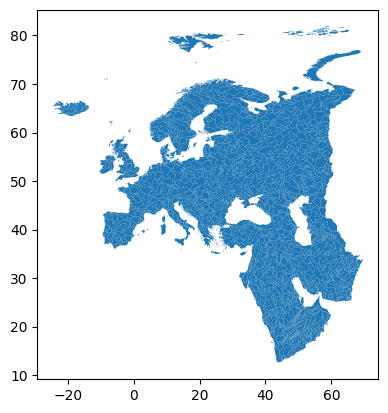

In [6]:
basin_lv6.geometry.plot()

<Axes: >

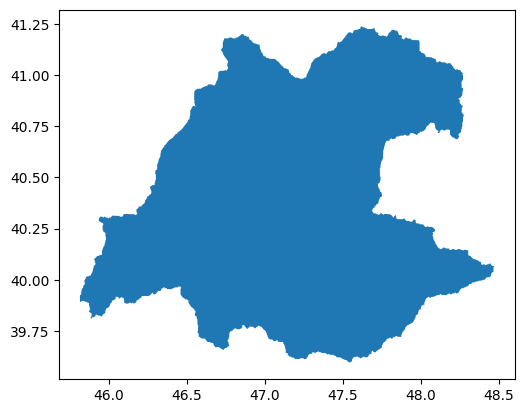

In [ ]:
basin = basin_lv6[basin_lv6['HYBAS_ID']==2060643510]
basin.geometry.plot()

In [16]:
basin

,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT,geometry
1416,2060643510,2060645200,2060070050,2060070050,197.5,197.5,23742.7,83523.1,284650,0,0,1,1417,"POLYGON ((47.59583 39.625, 47.58529 39.62443, ..."


In [ ]:
from shapely import wkt
from shapely.geometry import box
import pystac_client
from shapely.geometry import Polygon, shape
from pystac import ItemCollection
import planetary_computer

def query_nasadem_by_geometry(geometry):
    """Query NASADEM items using STAC API spatial search"""
    
    # Create STAC client
    catalog = pystac_client.Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1"
    )
    
    # Search for NASADEM items intersecting the geometry
    search = catalog.search(
        collections=["nasadem"],
        intersects=geometry.__geo_interface__,
        max_items=50  # Adjust based on your needs
    )
    
    items = search.item_collection()
    print(f"Found {len(items)} NASADEM items")
    
    return items
    

# geometry = wkt.loads(basin.geometry)
bbox = list(basin.total_bounds)
min_lon, min_lat, max_lon, max_lat = bbox
bbox_geometry = box(min_lon, min_lat, max_lon, max_lat)

# Query NASADEM for Armenia
items = query_nasadem_by_geometry(bbox_geometry)

# Sign and download items
signed_items = [planetary_computer.sign(item) for item in items]
tile_names = [item.id for item in signed_items]
tile_names

<Axes: >

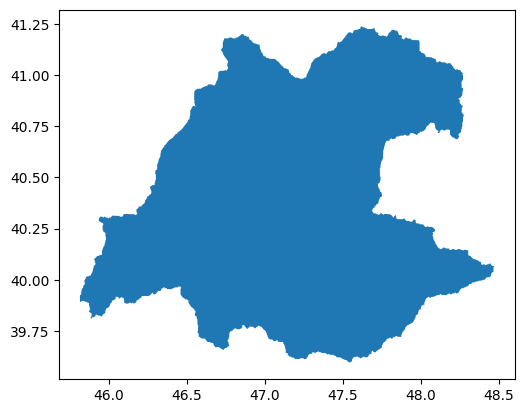

In [28]:
basin.geometry.plot()

In [ ]:
import pystac_client
from shapely.geometry import Polygon, shape
from pystac import ItemCollection

def query_nasadem_by_geometry(geometry):
    """Query NASADEM items using STAC API spatial search"""
    
    # Create STAC client
    catalog = pystac_client.Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1"
    )
    
    # Search for NASADEM items intersecting the geometry
    search = catalog.search(
        collections=["nasadem"],
        intersects=geometry.__geo_interface__,
        max_items=50  # Adjust based on your needs
    )
    
    items = search.item_collection()
    print(f"Found {len(items)} NASADEM items")
    
    return items

armenia_coords = [
    [[44.51121478890229, 42.146512694226736],
     [43.35765033577729, 41.67230556767255],
     [43.01707416390229, 40.746642072199016],
     [43.11595111702729, 40.22021024079329],
     [44.03880267952729, 39.75725604555278],
     [44.58155903918743, 39.01329095452977],
     [45.10447650765229, 38.42713768393307],
     [46.03831439827729, 38.15983810716374],
     [47.73020892952729, 38.452953108894604],
     [48.58714252327729, 38.710599214984924],
     [49.23575441701758, 38.85912608435862],
     [50.07918844521933, 39.46965640273313],
     [50.74046283577729, 40.29566747583251],
     [50.28394326231337, 40.87508963611984],
     [49.73277149957145, 41.243868022139445],
     [48.74095111702729, 41.66409870087408],
     [48.05979877327729, 41.901672954135805],
     [46.66453510140229, 41.93437272317577],
     [45.68675189827729, 41.950716324168894]]
]

# Create Shapely polygon
armenia_polygon = Polygon([(lon, lat) for lon, lat in armenia_coords[0]])

# Query NASADEM for Armenia
items = query_nasadem_by_geometry(armenia_polygon)

# Sign and download items
signed_items = [planetary_computer.sign(item) for item in items]
tile_names = [item.id for item in signed_items]
tile_names

Found 30 NASADEM items


['NASADEM_HGT_n42e045',
 'NASADEM_HGT_n42e044',
 'NASADEM_HGT_n41e049',
 'NASADEM_HGT_n41e048',
 'NASADEM_HGT_n41e047',
 'NASADEM_HGT_n41e046',
 'NASADEM_HGT_n41e045',
 'NASADEM_HGT_n41e044',
 'NASADEM_HGT_n41e043',
 'NASADEM_HGT_n40e050',
 'NASADEM_HGT_n40e049',
 'NASADEM_HGT_n40e048',
 'NASADEM_HGT_n40e047',
 'NASADEM_HGT_n40e046',
 'NASADEM_HGT_n40e045',
 'NASADEM_HGT_n40e044',
 'NASADEM_HGT_n40e043',
 'NASADEM_HGT_n39e049',
 'NASADEM_HGT_n39e048',
 'NASADEM_HGT_n39e047',
 'NASADEM_HGT_n39e046',
 'NASADEM_HGT_n39e045',
 'NASADEM_HGT_n39e044',
 'NASADEM_HGT_n39e043',
 'NASADEM_HGT_n38e049',
 'NASADEM_HGT_n38e048',
 'NASADEM_HGT_n38e047',
 'NASADEM_HGT_n38e046',
 'NASADEM_HGT_n38e045',
 'NASADEM_HGT_n38e044']

In [3]:
from tqdm import tqdm 
import pystac
import planetary_computer
import rioxarray

def download_nasadem_tiles(tile_list, output_dir=None):
    """
    Download multiple NASADEM tiles
    
    Parameters:
    - tile_list: List of tile names ['NASADEM_HGT_n40e049', 'NASADEM_HGT_n41e049']
    - output_dir: Directory to save files (optional)
    """
    datasets = {}
    
    for tile_name in tqdm(tile_list, desc="Downloading DEM tiles"):
        try:
            item_url = f"https://planetarycomputer.microsoft.com/api/stac/v1/collections/nasadem/items/{tile_name}"
            item = pystac.Item.from_file(item_url)
            signed_item = planetary_computer.sign(item)
            
            asset_href = signed_item.assets["elevation"].href
            ds = rioxarray.open_rasterio(asset_href)
            
            datasets[tile_name] = ds
            
            # Save to file if output directory specified
            if output_dir:
                import os
                os.makedirs(output_dir, exist_ok=True)
                output_path = f"{output_dir}/{tile_name}.tif"
                ds.rio.to_raster(output_path)
                print(f"Saved: {output_path}")
                
        except Exception as e:
            print(f"Failed to download {tile_name}: {e}")
    
    return datasets

# Usage
dem_datasets = download_nasadem_tiles(tile_list=tile_names, output_dir="outputs/strm_dem_tiles")

Saved: outputs/strm_dem_tiles/NASADEM_HGT_n42e045.tif


Saved: outputs/strm_dem_tiles/NASADEM_HGT_n42e044.tif


Saved: outputs/strm_dem_tiles/NASADEM_HGT_n41e049.tif


Saved: outputs/strm_dem_tiles/NASADEM_HGT_n41e048.tif


Saved: outputs/strm_dem_tiles/NASADEM_HGT_n41e047.tif


...

Saved: outputs/strm_dem_tiles/NASADEM_HGT_n38e048.tif


Saved: outputs/strm_dem_tiles/NASADEM_HGT_n38e047.tif


Saved: outputs/strm_dem_tiles/NASADEM_HGT_n38e046.tif


Saved: outputs/strm_dem_tiles/NASADEM_HGT_n38e045.tif


Saved: outputs/strm_dem_tiles/NASADEM_HGT_n38e044.tif
